In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

def visualize_decision_tree(max_depth, X, y, ax=None):
    """
    Visualize the decision boundary of a Decision Tree for a given max_depth.

    Parameters:
    - max_depth (int or None): Depth of the decision tree. 
                               Use None for a fully grown tree.
    - X (array-like): Feature matrix with 2 features.
    - y (array-like): Target labels.
    - ax (matplotlib axis, optional): Axis to plot on for subplotting.
    """
    
    # Train the model
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X, y)

    # Create meshgrid
    h = 0.02  # Step size
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    # Predict over the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Use provided axis or create a new one
    if ax is None:
        ax = plt.gca()

    # Plot decision boundary
    contour = ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

    # Plot data points
    scatter = ax.scatter(
        X[:, 0], X[:, 1],
        c=y,
        edgecolor='k',
        cmap=plt.cm.RdYlBu,
        s=40
    )

    # Set title based on depth
    depth_label = "None (Overfitting)" if max_depth is None else f"{max_depth}"
    ax.set_title(f"Decision Tree (max_depth = {depth_label})")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

    return model

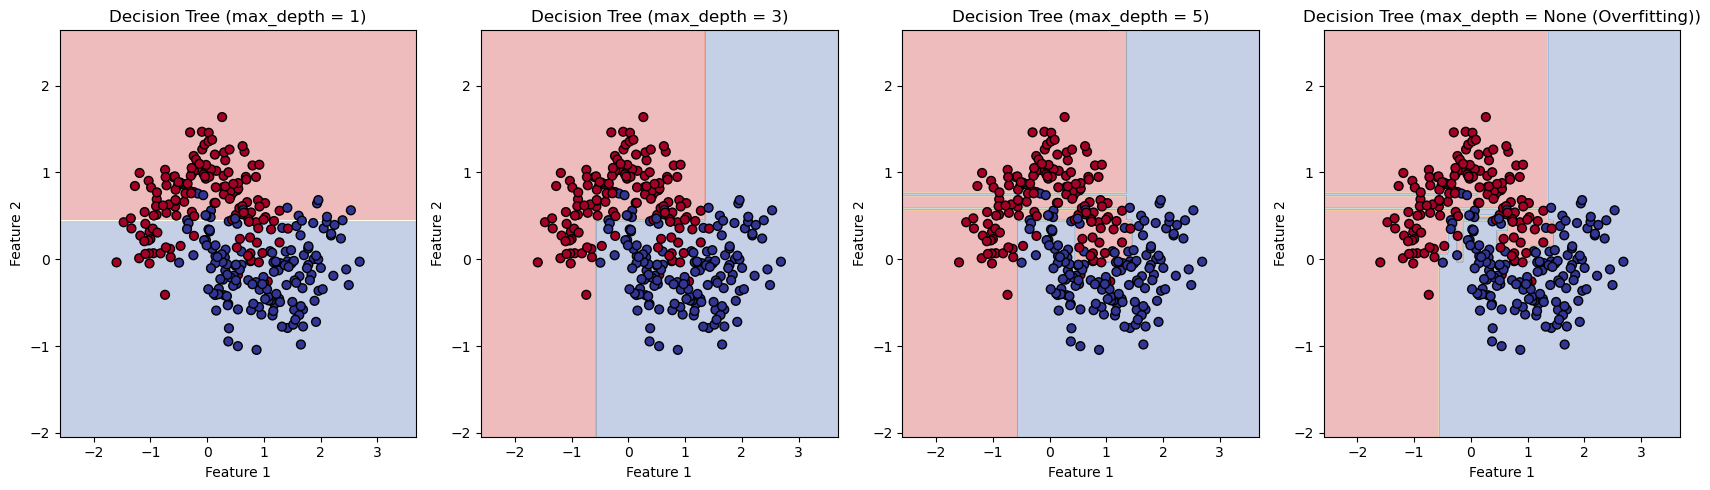

In [10]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generate dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Visualize different depths
depths = [1, 3, 5, None]

fig, axes = plt.subplots(1, len(depths), figsize=(17, 5))

for ax, depth in zip(axes, depths):
    visualize_decision_tree(depth, X, y, ax=ax)

plt.tight_layout()
plt.show()